
<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(9, 169, 36, 0.72); padding: 20px; border-radius: 10px; color: white;">
  <img src="logo_udea.png" alt="Logo UdeA" style="height: 80px;">
  <div>
    <h1 style="margin: 0; font-size: 2em;">Proyecto 3. - Parte 2: Implementación y dataframe</h1>
    <p style="margin: 2px 0 0 0; font-size: 1.3em;"><strong>Bioseñales y Sistemas</strong></p>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Universidad de Antioquia - Facultad de Ingeniería</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Integrantes: Luisa Taho, Liseth Tiria, Victor Ocampo</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Profesores: John Fredy Ochoa, Juliana Moreno Rada</p>
  </div>
</div>

## Importación de librerías

In [ ]:
import os
import pandas as pd
import numpy as np
import pywt
from scipy.signal import iirfilter, filtfilt, welch
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu
from scipy.stats import kstest, mannwhitneyu

### Extracción de las señales de la derivación II

In [ ]:
# Ruta base y nombres de columnas
columnas = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
ruta = os.path.join(directorio_actual, "ECGData", "ECGData")

# Cargar Excel y renombrar columnas
archivo_excel = r'C:\Programación\Bioseñales\Laboratorio y proyectos\proy3\Diagnostics.xlsx'
data = pd.read_excel(archivo_excel)
dataframe_ritmos = data[["FileName", "Rhythm"]].copy()
dataframe_ritmos.rename(columns={"FileName": "Registro", "Rhythm": "Ritmo"}, inplace=True)

# Función corregida para leer derivación II limpiamente
def derivacion_dos(carpeta, archivo, columnas): 
    ruta_archivo = os.path.join(carpeta, archivo + ".csv")
    try:
        df = pd.read_csv(ruta_archivo, delimiter=',', names=columnas, skiprows=1)
        signal = pd.to_numeric(df["II"], errors="coerce").dropna().reset_index(drop=True)
        return signal
    except Exception as e:
        print(f"Error en {archivo}: {e}")
        return None

# Construcción del dataframe con la señal limpia
lista_derivacion_II = []

for _, fila in dataframe_ritmos.iterrows():
    archivo = fila["Registro"]
    ritmo = fila["Ritmo"]
    signal = derivacion_dos(ruta, archivo, columnas)
    if signal is not None and not signal.empty:
        lista_derivacion_II.append({
            "Registro": archivo,
            "Ritmo": ritmo,
            "II": signal
        })

df_signals = pd.DataFrame(lista_derivacion_II)
df_signals.index += 1  


In [13]:
df_signals

,Registro,Ritmo,II
1,MUSE_20180113_171327_27000,AFIB,0 263.52 1 263.52 2 263.52 3...
2,MUSE_20180112_073319_29000,SB,0 9.76 1 -19.52 2 -19.52 3 ...
3,MUSE_20180111_165520_97000,SA,0 -63.44 1 -53.68 2 -43.92 3 ...
4,MUSE_20180113_121940_44000,SB,0 107.36 1 107.36 2 107.36 3...
5,MUSE_20180112_122850_57000,AF,0 -146.40 1 -126.88 2 -126.88 3...
...,...,...,...
10642,MUSE_20181222_204306_99000,SVT,0 -34.16 1 -19.52 2 -9.76 3...
10643,MUSE_20181222_204309_22000,SVT,0 -610.00 1 -570.96 2 -541.68 3...
10644,MUSE_20181222_204310_31000,SVT,0 -19.52 1 0.00 2 14.64 3...
10645,MUSE_20181222_204312_58000,SVT,0 -483.12 1 -453.84 2 -405.04 3...


### Rutina de filtrado: Flujo 1

El filtrado se compone de los siguientes pasos:

1. Filtro pasaaltas IIR a 0.5 Hz
Se utiliza un filtro Butterworth de cuarto orden para eliminar el desplazamiento de línea base (baseline wander) y otras componentes de muy baja frecuencia. Este paso mejora la estabilidad de la señal y permite resaltar los eventos de interés como los complejos QRS.

2. Filtrado wavelet adaptado con umbralización suave
La señal filtrada se descompone en múltiples niveles utilizando la transformada wavelet discreta con la función base Daubechies 4 (db4) hasta el nivel 5.
Los coeficientes de detalle se suavizan aplicando un umbral global, calculado a partir de la desviación estándar robusta (basada en la mediana) y la longitud de la señal.
Se aplica un soft-thresholding a los coeficientes, lo cual permite reducir ruido sin eliminar completamente las componentes de interés. Finalmente, se reconstruye la señal filtrada.

3. Filtro pasabajas IIR a 50 Hz
Se aplica un filtro Butterworth de tercer orden para eliminar componentes de alta frecuencia, como ruido muscular (EMG) o interferencias industriales. Esto permite conservar el contenido frecuencial relevante del ECG (normalmente < 40 Hz).

Finalmente se realiza la Estimación de la frecuencia de máxima potencia (fMP). A la señal filtrada se le calcula la densidad espectral de potencia utilizando el método de Welch.
La frecuencia correspondiente al valor máximo de la PSD se guarda como fMP, la cual representa la frecuencia dominante en la señal ECG filtrada.

In [ ]:
#Función para filtrar la señal ECG y calcular la frecuencia de máxima potencia
def flujo1(df_signals, fs=500):
    resultados = []

    for _, fila in df_signals.iterrows():
        signal = fila["II"]
        registro = fila["Registro"]
        ritmo = fila["Ritmo"]

        # Paso 1. Filtro pasaaltas IIR a 0.5 Hz
        nyquist = fs / 2
        b_hp, a_hp = iirfilter(N=4, Wn=0.5 / nyquist, btype='highpass', ftype='butter')
        sig_hp = filtfilt(b_hp, a_hp, signal)

        # Paso 2. Filtrado wavelet adaptado
        def wavelet_filter_ecg(signal, wavelet='db4', level=5):
            def wnoisest(coeff):
                stdc = np.zeros((len(coeff), 1))
                for i in range(len(coeff)):
                    stdc[i] = np.median(np.abs(coeff[i])) / 0.6745
                return stdc

            def threshold(coeff):
                num_samples = sum(c.shape[0] for c in coeff)
                return np.sqrt(2 * np.log(num_samples))

            def wthresh(coeff):
                stds = wnoisest(coeff)
                thr = threshold(coeff)
                filtered = []
                for i, c in enumerate(coeff):
                    filtered.append(pywt.threshold(c, value=thr * stds[i], mode='soft'))
                return filtered

            coeffs = pywt.wavedec(signal, wavelet, level=level)
            approx = coeffs[0]
            details = coeffs[1:]
            details_thresh = wthresh(details)
            coeffs_filt = [approx] + details_thresh
            return pywt.waverec(coeffs_filt, wavelet)[:len(signal)]

        sig_wav = wavelet_filter_ecg(sig_hp)

        # 3. Filtro pasabajas IIR a 50 Hz
        b_lp, a_lp = iirfilter(N=3, Wn=50 / nyquist, btype='lowpass', ftype='butter')
        sig_lp = filtfilt(b_lp, a_lp, sig_wav)

        # 4. Welch para obtener frecuencia de máxima potencia
        freqs, psd = welch(sig_lp, fs=fs, nperseg=1024)
        fmp = freqs[np.argmax(psd)]

        # Guardamos resultados
        resultados.append({
            "Registro": registro,
            "Ritmo": ritmo,
            "fMP": fmp,
            "SeñalFiltrada": sig_lp  
        })

    return pd.DataFrame(resultados)


In [16]:
df_fmp_resultados = flujo1(df_signals)


Este dataframe corresponde al solicitado en el punto 6, sin embargo se le añadió el valor de señal filtrada por facilidad para cálculos posteriores y la columna 'estado' se renombró por ritmo para mantener consistencia con trabajos anteriores

In [17]:
df_fmp_resultados

,Registro,Ritmo,fMP,SeñalFiltrada
0,MUSE_20180113_171327_27000,AFIB,0.488281,"[-151.6317063446392, -162.997582846871, -174.4..."
1,MUSE_20180112_073319_29000,SB,0.976562,"[-17.326167800859345, -17.99992209374653, -18...."
2,MUSE_20180111_165520_97000,SA,0.976562,"[15.227998658108477, 15.140427679832781, 15.09..."
3,MUSE_20180113_121940_44000,SB,3.417969,"[-0.11482609466616928, -2.4652966047948213, -4..."
4,MUSE_20180112_122850_57000,AF,5.371094,"[-35.11250867374927, -34.92898588272276, -34.7..."
...,...,...,...,...
10641,MUSE_20181222_204306_99000,SVT,3.417969,"[-5.801910349020208, -6.228870425979678, -6.53..."
10642,MUSE_20181222_204309_22000,SVT,2.929688,"[-197.53118644062639, -197.20727794971106, -19..."
10643,MUSE_20181222_204310_31000,SVT,2.441406,"[143.5607549294348, 151.3217853224844, 158.632..."
10644,MUSE_20181222_204312_58000,SVT,2.929688,"[130.88892751276722, 146.67957395680932, 162.1..."


## Análisis estadístico de los datos

Resumen estadístico por ritmo:
        count      mean       std       min       25%       50%       75%  \
Ritmo                                                                       
AF      445.0  3.437719  1.499492  0.488281  2.441406  3.417969  4.394531   
AFIB   1780.0  2.872630  1.590584  0.488281  1.464844  2.929688  3.906250   
AT      121.0  3.482535  1.506227  0.488281  2.441406  3.906250  4.882812   
AVNRT    16.0  4.974365  1.225171  2.929688  4.516602  5.615234  5.859375   
AVRT      8.0  4.821777  0.956743  3.417969  4.272461  4.882812  5.126953   
SA      399.0  2.719200  1.689658  0.488281  0.976562  2.929688  3.906250   
SAAWR     7.0  2.441406  1.409547  0.976562  0.976562  2.929688  3.662109   
SB     3889.0  1.902275  1.445052  0.488281  0.976562  0.976562  2.929688   
SR     1826.0  3.212602  1.665577  0.488281  1.464844  3.417969  4.394531   
ST     1568.0  4.158176  1.881693  0.488281  1.953125  4.882812  5.371094   
SVT     587.0  4.121693  1.460215  0.488281  

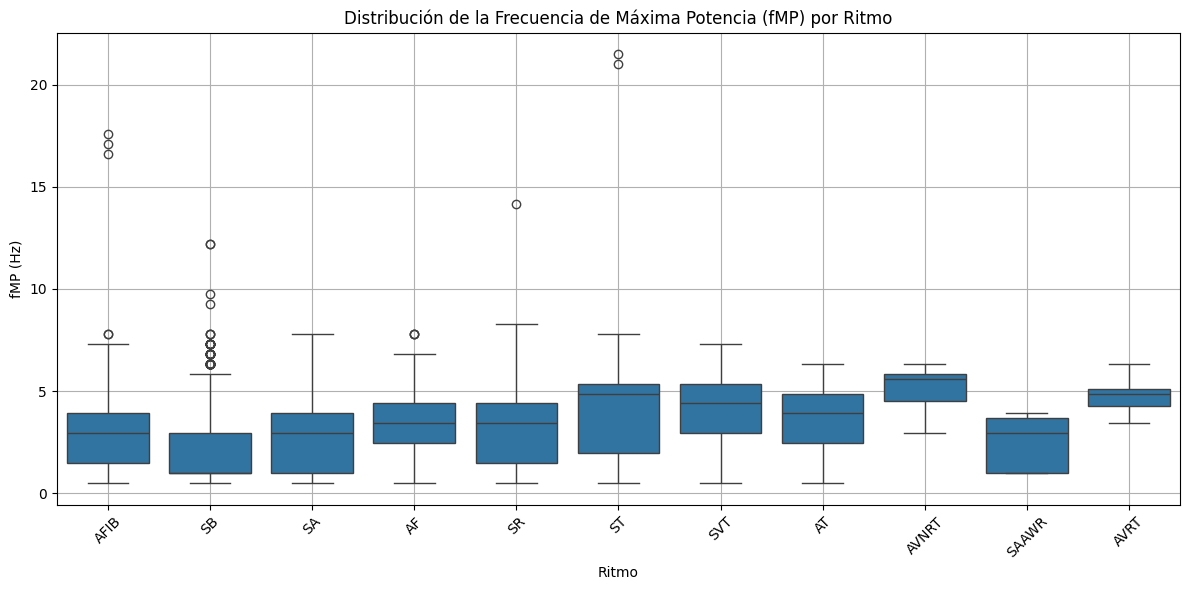

In [ ]:

# 1. Estadística descriptiva por ritmo
summary_stats = df_fmp_resultados.groupby("Ritmo")["fMP"].describe()
print("Resumen estadístico por ritmo:")
print(summary_stats)

#Boxplot de la frecuencia de máxima potencia por ritmo
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_fmp_resultados, x="Ritmo", y="fMP")
plt.xticks(rotation=45)
plt.title("Distribución de la Frecuencia de Máxima Potencia (fMP) por Ritmo")
plt.xlabel("Ritmo")
plt.ylabel("fMP (Hz)")
plt.grid(True)
plt.tight_layout()
plt.show()




### Cálculo de fmp de las señales filtradas del dataset Chapman ECG

In [30]:
def procesar_fmp_desde_directorio(ruta_base, fs=500):
    ritmos = ["AFIB", "SB", "SR"]
    resultados = []

    for ritmo in ritmos:
        carpeta = os.path.join(ruta_base, ritmo)
        archivos = [f for f in os.listdir(carpeta) if f.endswith(".csv")]

        for archivo in archivos:
            ruta_archivo = os.path.join(carpeta, archivo)
            try:
                signal = pd.read_csv(ruta_archivo, header=None).squeeze("columns")
                signal = pd.to_numeric(signal, errors="coerce").dropna()

                if signal.empty:
                    print(f"Señal vacía en {archivo}")
                    continue

                fmp = obtener_fMP(signal, fs=fs)
                resultados.append({
                    "Registro": archivo.replace(".csv", ""),
                    "Ritmo": ritmo,
                    "fMP_previa": fmp
                })

            except Exception as e:
                print(f"Error en {archivo}: {e}")

    return pd.DataFrame(resultados)


In [31]:
ruta_base = r"C:\Programación\Bioseñales\Laboratorio y proyectos\proyecto2_ecg_"
df_fmp_previos = procesar_fmp_desde_directorio(ruta_base)


In [32]:
df_fmp_previos

,Registro,Ritmo,fMP_previa
0,MUSE_20180111_155154_74000,AFIB,4.882812
1,MUSE_20180111_155203_15000,AFIB,3.906250
2,MUSE_20180111_155903_57000,AFIB,2.441406
3,MUSE_20180111_155945_02000,AFIB,3.906250
4,MUSE_20180111_160053_89000,AFIB,3.417969
...,...,...,...
7490,MUSE_20180210_133122_64000,SR,4.882812
7491,MUSE_20180210_133123_70000,SR,7.324219
7492,MUSE_20180210_133136_06000,SR,5.859375
7493,MUSE_20180210_133138_18000,SR,8.300781


### Gráficos comparativos

In [84]:
# Filtrar solo los ritmos deseados
ritmos_interes = ["AFIB", "SB", "SR"]
df_fmp_resultados_filtrado = df_fmp_resultados[df_fmp_resultados["Ritmo"].isin(ritmos_interes)].copy()
df_fmp_previos_filtrado = df_fmp_previos[df_fmp_previos["Ritmo"].isin(ritmos_interes)].copy()

# Preparar para comparación
df_fmp_resultados_filtrado = df_fmp_resultados_filtrado.rename(columns={"fMP": "fMP_valor"})
df_fmp_resultados_filtrado["Origen"] = "Flujo 1"

df_fmp_previos_filtrado = df_fmp_previos_filtrado.rename(columns={"fMP_previa": "fMP_valor"})
df_fmp_previos_filtrado["Origen"] = "Artículo"

# Concatenar
df_comparacion_fmp = pd.concat([df_fmp_resultados_filtrado, df_fmp_previos_filtrado], ignore_index=True)


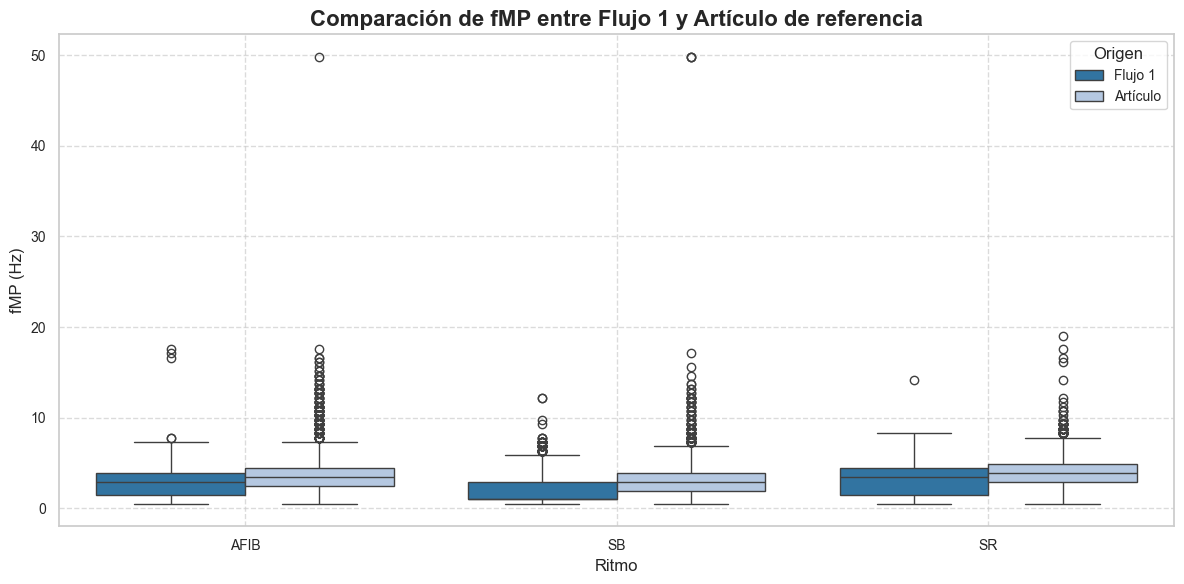

In [85]:

# Colores definidos manualmente
custom_palette = {"Flujo 1": "#1f77b4",    # azul oscuro
                  "Artículo": "#aec7e8"}   # azul claro

# Estética general
sns.set(style="whitegrid")
plt.figure(figsize=(12, 6))

# Boxplot con paleta personalizada
sns.boxplot(data=df_comparacion_fmp, x="Ritmo", y="fMP_valor", hue="Origen", palette=custom_palette)

# Títulos y etiquetas
plt.title("Comparación de fMP entre Flujo 1 y Artículo de referencia", fontsize=16, weight='bold')
plt.xlabel("Ritmo", fontsize=12)
plt.ylabel("fMP (Hz)", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# Leyenda
plt.legend(title="Origen", title_fontsize=12, fontsize=10)

# Cuadrícula y diseño ajustado
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()



C:\Users\tahol\AppData\Local\Temp\ipykernel_31076\2772834490.py:10: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:darkcyan'` for the same effect.

  sns.violinplot(data=df_comp, x="Ritmo", y="fMP_valor", hue="Origen", split=True, color ='darkcyan', inner="quartile")


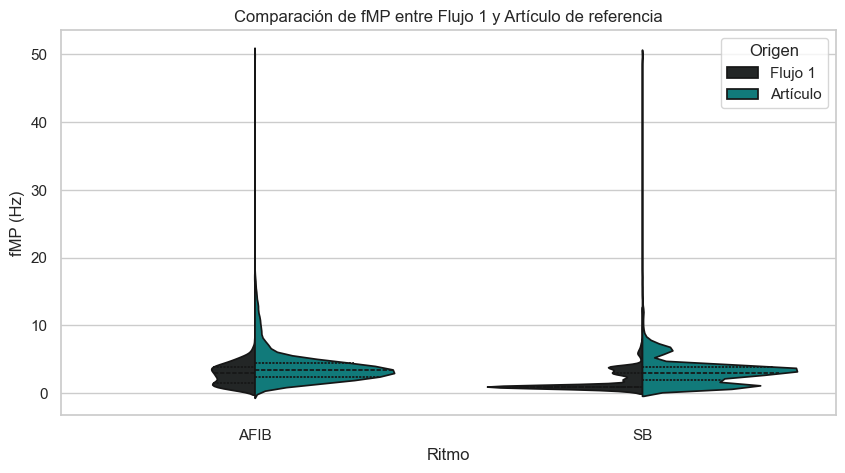

In [69]:
# Comparación de fMP entre Flujo 1 y Artículo ChapmanECG
ritmos_comparar = ["AFIB", "SB"]
df_comp = df_comparacion_fmp[df_comparacion_fmp["Ritmo"].isin(ritmos_comparar)].copy()

# Estilo general
sns.set(style="whitegrid")

# Violinplot
plt.figure(figsize=(10, 5))
sns.violinplot(data=df_comp, x="Ritmo", y="fMP_valor", hue="Origen", split=True, color ='darkcyan', inner="quartile")
plt.title("Comparación de fMP entre Flujo 1 y Artículo de referencia")
plt.ylabel("fMP (Hz)")
plt.xlabel("Ritmo")
plt.legend(title="Origen")
plt.show()



### Pruebas estadísticas

Se evaluaron diferencias en la frecuencia de máxima potencia (fMP) entre las señales procesadas con el Flujo 1 y las señales preprocesadas del artículo original, para los ritmos AFIB, SB y SR.

Se aplicó la prueba de normalidad Kolmogorov–Smirnov a ambos grupos en cada clase de ritmo, y en todos los casos se rechazó la hipótesis de normalidad (p < 0.05). Por tanto, se utilizó la prueba no paramétrica de Mann–Whitney U para comparar las distribuciones.

En los tres ritmos analizados se encontraron diferencias estadísticamente significativas entre ambos grupos (p < 0.05), lo cual indica que el tipo de procesamiento tiene un efecto relevante sobre la frecuencia dominante de las señales ECG.

In [57]:

resultados = {}

for ritmo in ["AFIB", "SB", "SR"]:
    grupo_flujo1 = df_comparacion_fmp[(df_comparacion_fmp["Ritmo"] == ritmo) &
                                      (df_comparacion_fmp["Origen"] == "Flujo 1")]["fMP_valor"]
    grupo_articulo = df_comparacion_fmp[(df_comparacion_fmp["Ritmo"] == ritmo) &
                                        (df_comparacion_fmp["Origen"] == "Artículo")]["fMP_valor"]

    # Prueba de normalidad: Kolmogorov-Smirnov
    p_norm1 = kstest(grupo_flujo1, "norm", args=(grupo_flujo1.mean(), grupo_flujo1.std())).pvalue
    p_norm2 = kstest(grupo_articulo, "norm", args=(grupo_articulo.mean(), grupo_articulo.std())).pvalue

    # Prueba de hipótesis
    if p_norm1 > 0.05 and p_norm2 > 0.05:
        stat, p_val = ttest_ind(grupo_flujo1, grupo_articulo, equal_var=False)
        prueba = "t-test"
    else:
        stat, p_val = mannwhitneyu(grupo_flujo1, grupo_articulo, alternative="two-sided")
        prueba = "Mann-Whitney U"

    resultados[ritmo] = {
        "n_flujo1": len(grupo_flujo1),
        "n_articulo": len(grupo_articulo),
        "p_norm_flujo1": p_norm1,
        "p_norm_articulo": p_norm2,
        "estadístico": stat,
        "p_valor": p_val
    }

# Mostrar resultados
df_resultado_final = pd.DataFrame(resultados).T

# Mostrar en output
df_resultado_final


,n_flujo1,n_articulo,p_norm_flujo1,p_norm_articulo,estadístico,p_valor
AFIB,1780.0,1780.0,2.711064e-14,1.104902e-66,1175547.5,7.171022e-41
SB,3889.0,3889.0,0.000000e+00,5.720620e-186,4427898.0,9.815362e-235
SR,1826.0,1826.0,1.166126e-24,6.861697e-46,1169980.5,1.768590e-55


### Pruebas estadísticas para evaluar la capacidad discriminativa de fMP

Las siguientes pruebas se hicieron con el objetivo de determinar cuál de los dos flujos (flujo 1 y flujo de referencia) permitía tener mayor capacidad discriminativa de la fMP 

#### Flujo 1

In [ ]:

# Filtrar fMP para AFIB y SB del Flujo 1
df_afib = df_fmp_resultados[df_fmp_resultados["Ritmo"] == "AFIB"]["fMP"]
df_sb = df_fmp_resultados[df_fmp_resultados["Ritmo"] == "SB"]["fMP"]

# Pruebas de normalidad con Kolmogorov-Smirnov (con distribución normal teórica)
p_norm_afib = kstest(df_afib, 'norm', args=(df_afib.mean(), df_afib.std())).pvalue
p_norm_sb = kstest(df_sb, 'norm', args=(df_sb.mean(), df_sb.std())).pvalue

# Comparación con Mann-Whitney U
stat, p_val = mannwhitneyu(df_afib, df_sb, alternative='two-sided')

# Crear DataFrame de resultados
res = pd.DataFrame({
    "n_AFIB": [len(df_afib)],
    "n_SB": [len(df_sb)],
    "media_AFIB": [df_afib.mean()],
    "media_SB": [df_sb.mean()],
    "p_norm_AFIB": [p_norm_afib],
    "p_norm_SB": [p_norm_sb],
    "estadístico": [stat],
    "p_valor": [p_val]
})

res


,n_AFIB,n_SB,media_AFIB,media_SB,p_norm_AFIB,p_norm_SB,estadístico,p_valor
0,1780,3889,2.87263,1.902275,2.711064e-14,0.0,4837538.5,1.768182e-137


#### Datos de referencia (proyecto 2)

In [87]:
# Filtrar señales del artículo (Proyecto 2) para SB y AFIB
df_afib_art = df_fmp_previos[df_fmp_previos["Ritmo"] == "AFIB"]["fMP_previa"]
df_sb_art = df_fmp_previos[df_fmp_previos["Ritmo"] == "SB"]["fMP_previa"]

# Prueba de normalidad (Kolmogorov–Smirnov)
p_norm_afib = kstest(df_afib_art, 'norm', args=(df_afib_art.mean(), df_afib_art.std())).pvalue
p_norm_sb = kstest(df_sb_art, 'norm', args=(df_sb_art.mean(), df_sb_art.std())).pvalue

# Prueba de hipótesis (Mann–Whitney U)
stat, p_mw = mannwhitneyu(df_afib_art, df_sb_art, alternative='two-sided')

# Construir DataFrame resumen
tabla_resultados_articulo = pd.DataFrame({
    "media_AFIB": [df_afib_art.mean()],
    "media_SB": [df_sb_art.mean()],
    "p_norm_AFIB": [p_norm_afib],
    "p_norm_SB": [p_norm_sb],
    "estadístico": [stat],
    "p_valor": [p_mw]
})

tabla_resultados_articulo

,media_AFIB,media_SB,p_norm_AFIB,p_norm_SB,estadístico,p_valor
0,3.931761,3.16799,1.104902e-66,5.720620e-186,4181772.0,5.768004e-37
